Fold 1: MSE=0.0420, MAE=0.1571, R²=0.5909


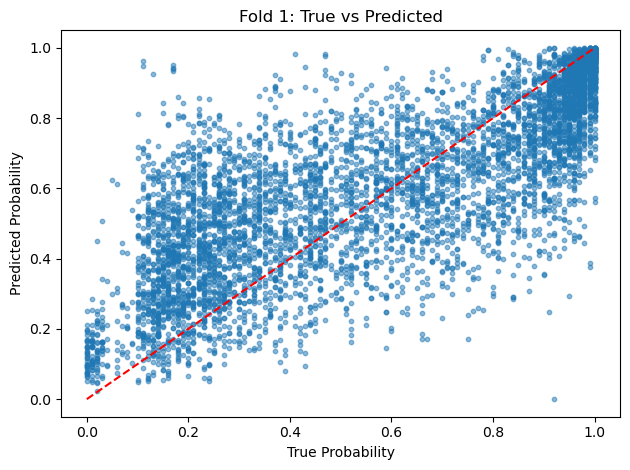

Fold 2: MSE=0.0424, MAE=0.1591, R²=0.5938


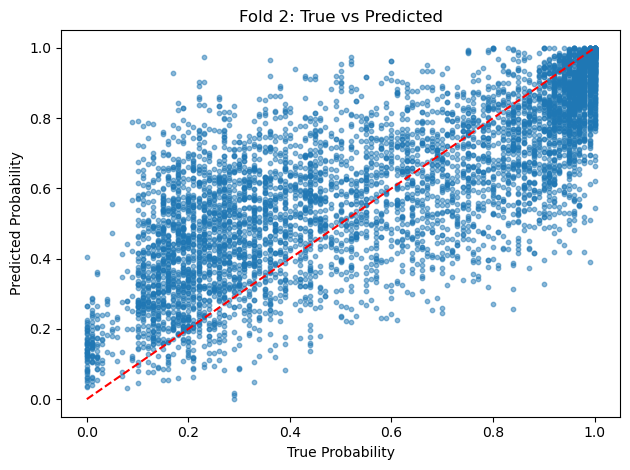

Fold 3: MSE=0.0400, MAE=0.1565, R²=0.6154


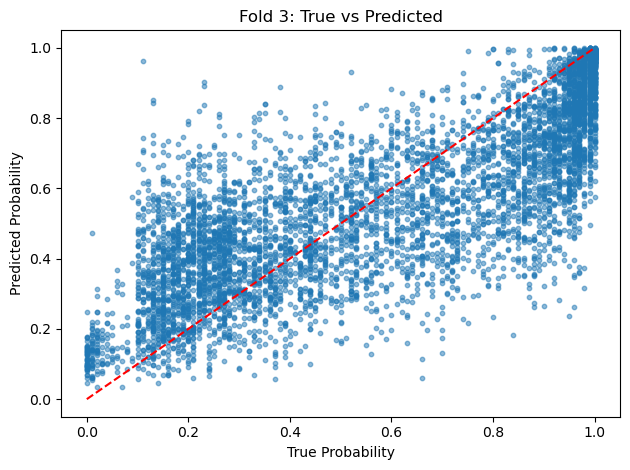

Fold 4: MSE=0.0414, MAE=0.1570, R²=0.5980


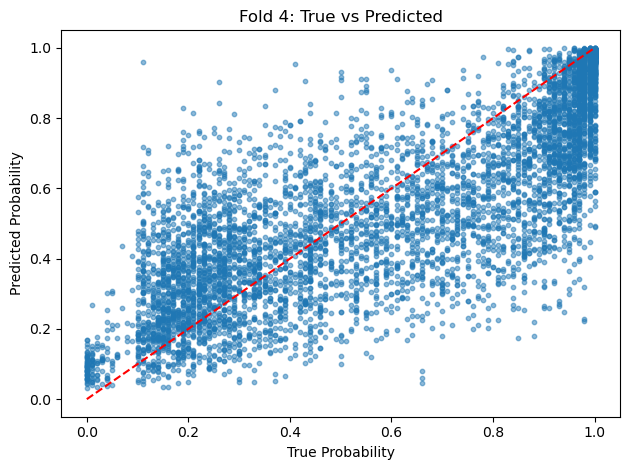

Fold 5: MSE=0.0414, MAE=0.1579, R²=0.6073


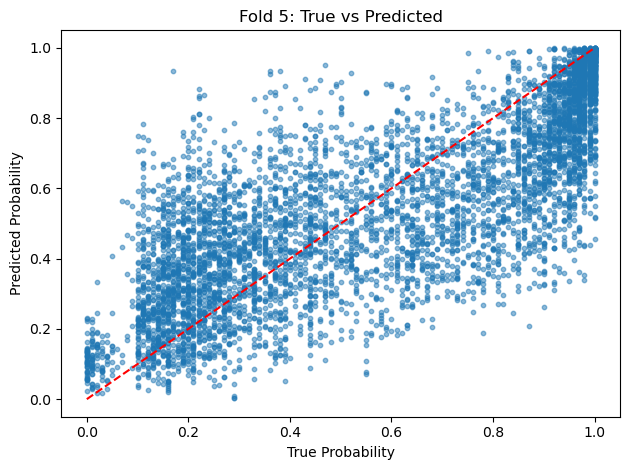

In [1]:
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

with open("fold_val_results.pkl", "rb") as f:
    fold_results = pickle.load(f)

for fold_num, fold in fold_results.items():
    labels = fold["all_labels"]
    preds = fold["all_preds"]
    mse = mean_squared_error(labels, preds)
    mae = mean_absolute_error(labels, preds)
    r2 = r2_score(labels, preds)
    print(f"Fold {fold_num}: MSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")
    plt.figure()
    plt.scatter(labels, preds, alpha=0.5, s=10)
    plt.xlabel("True Probability")
    plt.ylabel("Predicted Probability")
    plt.title(f"Fold {fold_num}: True vs Predicted")
    plt.plot([0, 1], [0, 1], 'r--')
    plt.tight_layout()
    plt.show()

Fold 1: MSE=0.0420, MAE=0.1571, R²=0.5909


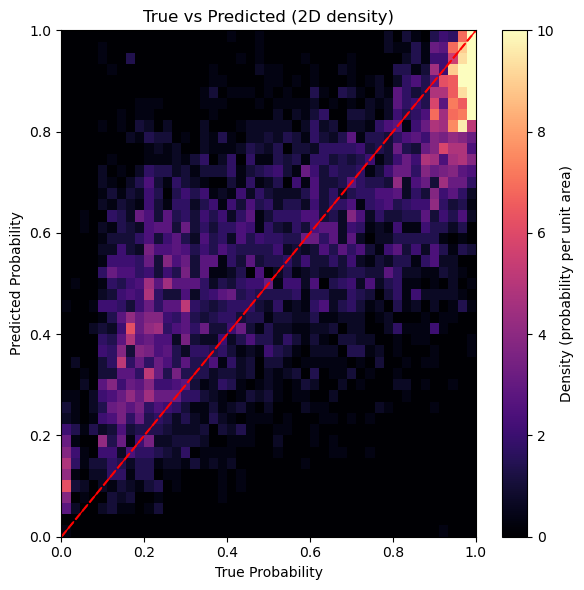

Fold 2: MSE=0.0424, MAE=0.1591, R²=0.5938


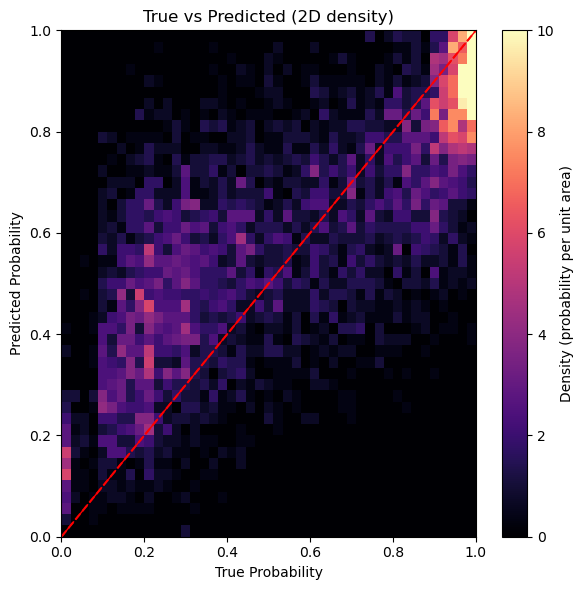

Fold 3: MSE=0.0400, MAE=0.1565, R²=0.6154


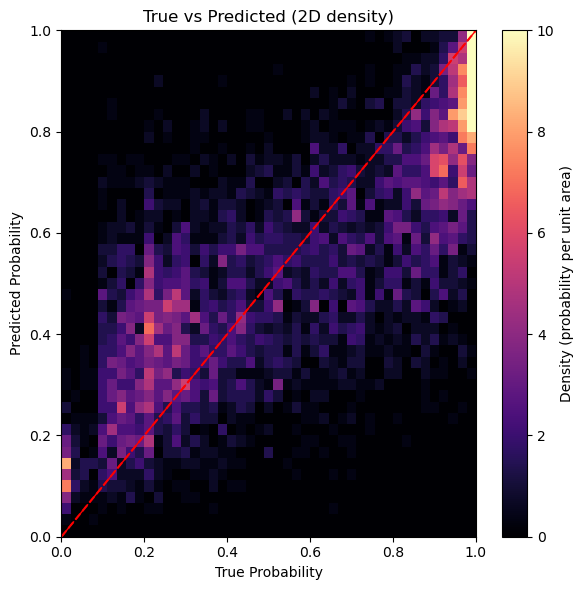

Fold 4: MSE=0.0414, MAE=0.1570, R²=0.5980


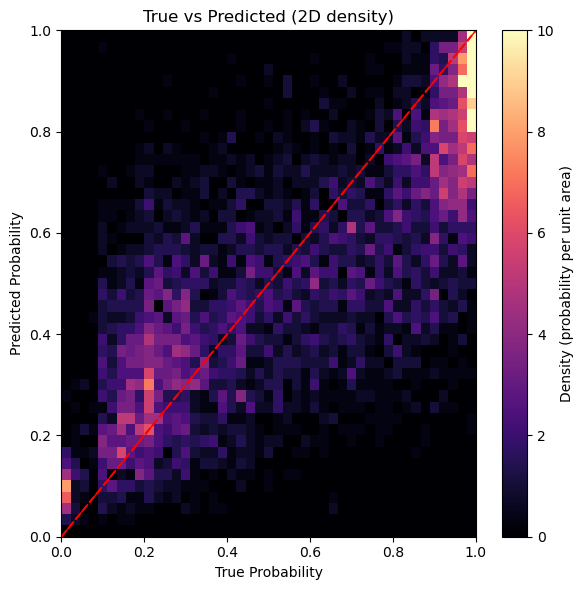

Fold 5: MSE=0.0414, MAE=0.1579, R²=0.6073


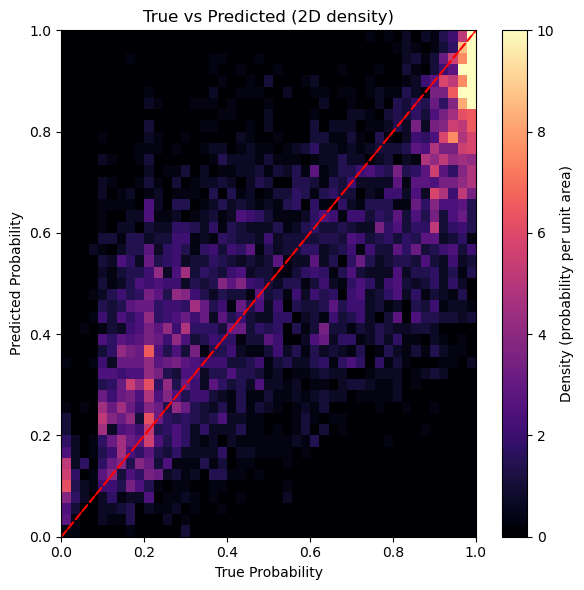

In [3]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

with open("fold_val_results.pkl", "rb") as f:
    fold_results = pickle.load(f)

for fold_num, fold in fold_results.items():
    labels = fold["all_labels"]
    preds = fold["all_preds"]
    mse = mean_squared_error(labels, preds)
    mae = mean_absolute_error(labels, preds)
    r2 = r2_score(labels, preds)
    print(f"Fold {fold_num}: MSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")
    

    # labels, preds already defined
    fig, ax = plt.subplots(figsize=(6,6))

    bins = 45
    H, xedges, yedges = np.histogram2d(labels, preds, bins=bins, range=[[0,1],[0,1]], density=True)
    # use only positive values for LogNorm
    # linear normalization (not log)
    pcm = ax.pcolormesh(xedges, yedges, H.T, cmap='magma', norm=mcolors.Normalize(vmin=0, vmax=10))
    ax.plot([0,1],[0,1],'r--', lw=1)
    ax.set_xlabel("True Probability")
    ax.set_ylabel("Predicted Probability")
    ax.set_title("True vs Predicted (2D density)")
    plt.colorbar(pcm, ax=ax, label='Density (probability per unit area)')

    plt.plot([0, 1], [0, 1], 'r--')
    plt.tight_layout()
    plt.show()

In [4]:
fold_num = list(fold_results.keys())[0]
labels = fold_results[fold_num]["all_labels"]
preds = fold_results[fold_num]["all_preds"]
for i in range(10):
    print(f"Sample {i}: True={labels[i]:.3f}, Pred={preds[i]:.3f}")

Sample 0: True=1.000, Pred=0.910
Sample 1: True=0.980, Pred=0.969
Sample 2: True=1.000, Pred=0.944
Sample 3: True=0.970, Pred=0.961
Sample 4: True=0.970, Pred=0.919
Sample 5: True=0.970, Pred=0.853
Sample 6: True=0.950, Pred=0.712
Sample 7: True=0.950, Pred=0.745
Sample 8: True=1.000, Pred=0.999
Sample 9: True=0.980, Pred=0.944
